# Multi-decade landfall density

Grid the density of North Atlantic track **fixes** over several decades within a US Gulf/East-coast bounding box to show climatological cyclone exposure. Uses point mode (one feature per fix) and a 2-D histogram.

IBTrACS gives the longest record; the first load is slow. Needs `pip install earthlens[tropycal]`.

In [1]:
from pathlib import Path

from earthlens import EarthLens

OUT_DIR = Path('tropycal_output')
OUT_DIR.mkdir(exist_ok=True)

fixes = None
try:
    fixes = EarthLens(
        variables=['north_atlantic'],
        data_source='tropycal',
        start='1980-01-01',
        end='2020-12-31',
        lat_lim=[20.0, 40.0],
        lon_lim=[-100.0, -70.0],
        source='ibtracs',
        path=str(OUT_DIR),
    ).download(progress_bar=False)
    print(len(fixes), 'fixes over 1980-2020')
except Exception as exc:
    print(f'skipped live query: {type(exc).__name__}: {exc}')

2026-05-23 18:04:57 | INFO | pyramids.base.config | Logging is configured.


C:\python-environments\pixi\envs\earthlens-7782220113782294872\envs\dev\Lib\site-packages\tropycal\_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


2026-05-23 18:04:59.294 | INFO     | earthlens.tropycal.backend:_get_track_dataset:378 - Loading tropycal TrackDataset(basin='north_atlantic', source='ibtracs'); the first load downloads + parses the whole basin best-track file and can be slow.


--> Starting to read in ibtracs data


--> Completed reading in ibtracs data (137.17 seconds)


2026-05-23 18:10:42 | INFO | pyogrio._io | Created 5,190 records


2026-05-23 18:10:42.306 | INFO     | earthlens.tropycal.backend:download:514 - Tropycal download summary: 5190 feature(s) across 1 file(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\tropycal\docs\examples\tropycal\tropycal_output


5190 fixes over 1980-2020


## Grid the fix density

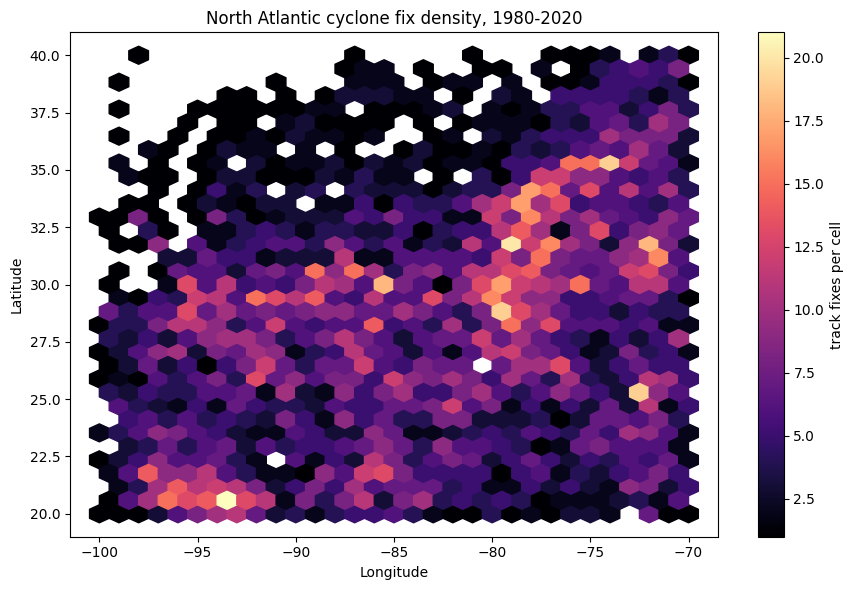

In [2]:
if fixes is not None and len(fixes):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 6))
    hb = ax.hexbin(fixes.geometry.x, fixes.geometry.y, gridsize=30,
                   cmap='magma', mincnt=1)
    fig.colorbar(hb, ax=ax, label='track fixes per cell')
    ax.set_title('North Atlantic cyclone fix density, 1980-2020')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()